In [364]:
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis, skew
from scipy.signal import find_peaks

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import ruptures as rpt


from sklearn.neighbors import KNeighborsClassifier


## Feature Extraction

In [365]:
def statistical_features(arr):
    vmin = np.amin(arr)
    vmax = np.amax(arr)
    mean = np.mean(arr)
    std = np.std(arr)
    return vmin, vmax, mean, std

def shape_features(arr):
    skewness = skew(arr)
    kurt = kurtosis(arr)
    return skewness, kurt

In [366]:
user = 'DF'

## Pre-processing

In [367]:
import_path = f'{user}'
export_path = f'{user}'

rightEDAdatapath  = f'{import_path}/EDA.csv'
rightHRdatapath   = f'{import_path}/HR.csv'
rightTEMPdatapath = f'{import_path}/TEMP.csv'

In [368]:
rightHRdatapath = np.loadtxt(rightHRdatapath, delimiter = ',')
rightHRdatapath = np.repeat(rightHRdatapath, 4)
np.savetxt('hr_new.csv', rightHRdatapath, delimiter = ',')

In [369]:
edat =  pd.read_csv(f'{user}/EDA.csv',  header = 2,  names = ['EDA'])
hrt =   pd.read_csv(f'hr_new.csv',      header = 12, names = ['HR'])
tempt = pd.read_csv(f'{user}/TEMP.csv', header = 2,  names = ['TEMP'])
gt =    pd.read_csv(f'{user}/EDA.csv',  nrows  = 1)

In [370]:
reference_time = gt.iloc[0,0]
min_len = min(len(edat), len(hrt), len(tempt))

eda = edat.iloc[:min_len, 0]
hrt = hrt.iloc[:min_len, 0]
tempt = tempt.iloc[:min_len, 0]
df_original = pd.concat([eda, hrt, tempt], axis = 1)

In [371]:
array = df_original.values
data = pd.DataFrame(array)
data.columns = ['EDA','HR','temp']

cols = [
    'EDA_Mean','EDA_Min','EDA_Max','EDA_Std', 'EDA_Kurtosis', 'EDA_Skew','EDA_Num_Peaks','EDA_Amphitude','EDA_Duration',
    'HR_Mean','HR_Min','HR_Max','HR_Std','HR_RMS','temp_Mean', 'temp_Min','temp_Max','temp_Std'
]
df_features = pd.DataFrame(columns=cols)

index = 0

for i in range(0,len(data['EDA']), 20):
    df_partial = data.iloc[i:i+40,]
    plen = len(df_partial['EDA'])
    
    if plen < 40:
        continue
    
    eda = df_partial['EDA'].values
    hr = df_partial['HR'].values
    temp = df_partial['temp'].values

    eda_min, eda_max, eda_mean, eda_std = statistical_features(eda)
    hr_min, hr_max, hr_mean, hr_std = statistical_features(hr)
    temp_min, temp_max, temp_mean, temp_std = statistical_features(temp)
    eda_skew, eda_kurtosis = shape_features(eda)
    
    hr_rms = np.sqrt(np.mean(np.square(np.ediff1d(hr))))
    temp_rms= np.sqrt(np.mean(np.square(np.ediff1d(temp))))

    peaks,properties = find_peaks(eda, width=5)
    num_Peaks = len(peaks)
    
    prominences = np.array(properties['prominences'])
    widths = np.array(properties['widths'])
    amphitude = np.sum(prominences)
    duration = np.sum(widths)

    df_features.loc[index] = [eda_mean, eda_min, eda_max, eda_std, eda_kurtosis, eda_skew, num_Peaks, amphitude, duration, hr_mean, hr_min, hr_max, hr_std,hr_rms, temp_mean, temp_min, temp_max, temp_std]

    index = index+1

In [372]:
cols = list(map(str, range(30, 0, -1)))
df_lag_features = pd.DataFrame(columns=cols)
df_lag_features = pd.concat([
    df_features['HR_Mean'].shift(10),  df_features['HR_Mean'].shift(9),    df_features['HR_Mean'].shift(8),
    df_features['HR_Mean'].shift(7),   df_features['HR_Mean'].shift(6),    df_features['HR_Mean'].shift(5),
    df_features['HR_Mean'].shift(4),   df_features['HR_Mean'].shift(3),    df_features['HR_Mean'].shift(2),
    df_features['HR_Mean'].shift(1),   df_features['temp_Mean'].shift(10), df_features['temp_Mean'].shift(9),
    df_features['temp_Mean'].shift(8), df_features['temp_Mean'].shift(7),  df_features['temp_Mean'].shift(6),
    df_features['temp_Mean'].shift(5), df_features['temp_Mean'].shift(4),  df_features['temp_Mean'].shift(3),
    df_features['temp_Mean'].shift(2), df_features['temp_Mean'].shift(1),  df_features['EDA_Mean'].shift(10),
    df_features['EDA_Mean'].shift(9),  df_features['EDA_Mean'].shift(8),   df_features['EDA_Mean'].shift(7),
    df_features['EDA_Mean'].shift(6),  df_features['EDA_Mean'].shift(5),   df_features['EDA_Mean'].shift(4),
    df_features['EDA_Mean'].shift(3),  df_features['EDA_Mean'].shift(2),   df_features['EDA_Mean'].shift(1)], axis=1)
df_lag_features.columns = cols
df_lag_features = df_lag_features.dropna()

In [373]:
df_temp = df_features.iloc[30:3238, 0:31]
df_total = pd.concat([df_lag_features, df_temp], axis=1)

## Stress detection model

In [374]:
df_lag = pd.read_csv('combined_lagEDA.csv')
train_set = df_lag.iloc[:,0:48]
labels = df_lag.iloc[:,48:49]

#Create a random forest Classifier
clf = RandomForestClassifier(n_estimators=100,max_depth=15)

# Split our data
train, test, train_labels, test_labels = train_test_split(train_set, labels, test_size=0.33, random_state=30)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(train, train_labels.values.ravel())

y_pred = clf.predict(test)

f1score   = f1_score        (test_labels, y_pred, average = 'macro')
recall    = recall_score    (test_labels, y_pred, average = 'macro')
precision = precision_score (test_labels, y_pred, average = 'macro')
accuracy  = accuracy_score  (test_labels, y_pred)

print('acc =', accuracy)
print('pre =', precision)
print('recall =', recall) 
print('f1 =', f1score)

acc = 0.954954954954955
pre = 0.953459864740475
recall = 0.9377358612481336
f1 = 0.9447384335549612


## K-nearest neighbors (KNN)

In [375]:

df_lag = pd.read_csv('combined_lagEDA.csv')
train_set = df_lag.iloc[:,0:48]
labels = df_lag.iloc[:,48:49]

#Create a K-nearest neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)

# Split our data
train, test, train_labels, test_labels = train_test_split(train_set, labels, test_size=0.33, random_state=30)

#Train the model using the training sets knn_pred = knn.predict(knn_test)
scaler = MinMaxScaler()
knn_train = scaler.fit_transform(train)
knn_test = scaler.transform(test)
knn.fit(knn_train, train_labels.values.ravel())

knn_pred = knn.predict(knn_test)

f1score_knn   = f1_score        (test_labels, knn_pred , average = 'macro')
recall_knn    = recall_score    (test_labels, knn_pred , average = 'macro')
precision_knn = precision_score (test_labels, knn_pred , average = 'macro')
accuracy_knn  = accuracy_score  (test_labels, knn_pred )

print('acc =', accuracy_knn)
print('pre =', precision_knn)
print('recall =', recall_knn) 
print('f1 =', f1score_knn)

acc = 0.8775261748234722
pre = 0.8547921918945844
recall = 0.855204840615786
f1 = 0.8549789798393466


### Predicting the stress

In [376]:
df_total = df_total.dropna()
scalar = MinMaxScaler()
x_scaled = scalar.fit_transform(df_total.iloc[:,0:48])
data = pd.DataFrame(x_scaled)
data = data.fillna(0)

pred_t = clf.predict(data)
pred_t = pd.DataFrame(pred_t)
pred_t.columns=['pred']
pred_t.head(30)
pred_t.to_csv('pred'+user+'.csv')

/workspaces/Stress-Detection-in-Nurses/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [377]:
df_total['pred'] = pred_t['pred'].to_numpy()
df_total.to_csv(f'pred{user}.csv')

In [378]:
df_total['MA_3'] = np.ceil(df_total.iloc[:, 48:49].rolling(window=31).mean())

### Change detection

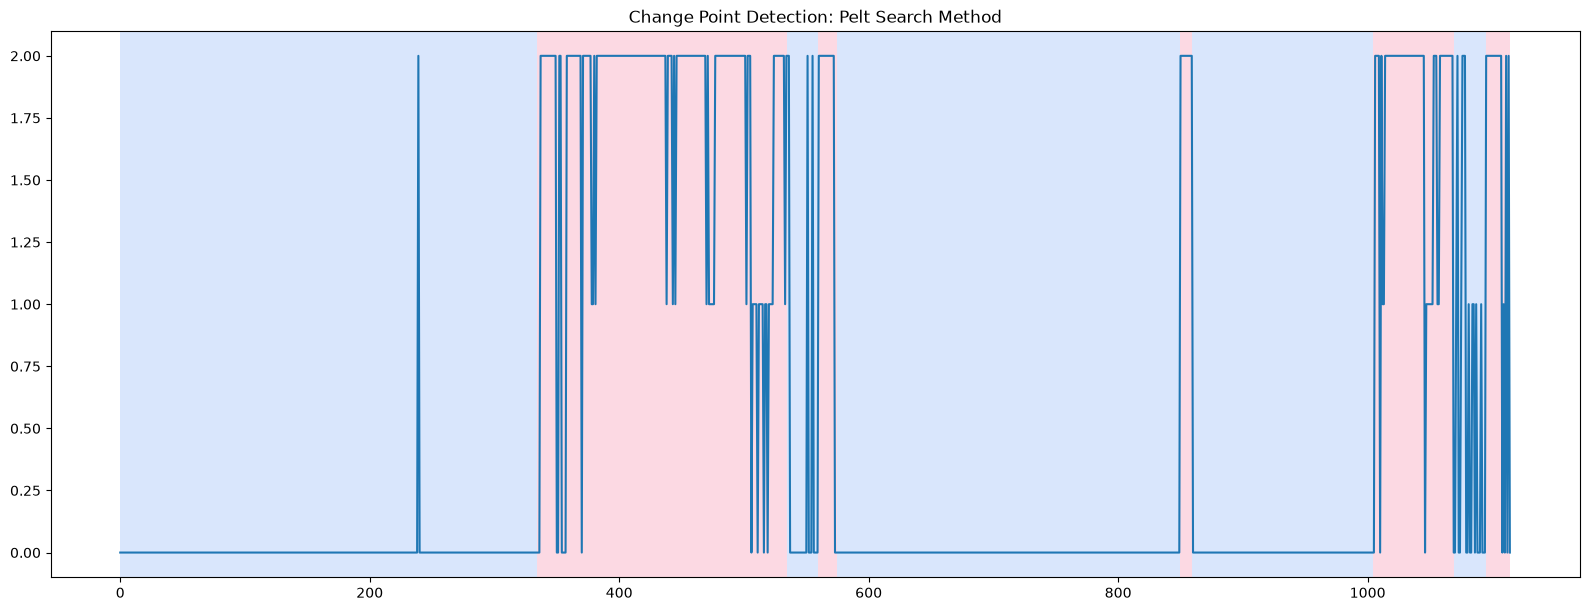

[0, 335, 535, 560, 575, 850, 860, 1005, 1070, 1095, 1115]


In [379]:
signal = df_total.iloc[:, 48:49].values.reshape(-1)

algo = rpt.Pelt(model="l2").fit(signal)
result = algo.predict(pen=10)

rpt.display(signal, result, figsize=(16, 6))
plt.title('Change Point Detection: Pelt Search Method')
plt.show()

result = [0] + result
print(result)

### Generating the event by start and end epoch_times

In [380]:
temp_start = 0
temp_end = result[0]

stress = []
for i in range(len(result) - 1):
    segment = df_total.iloc[result[i]:(result[i + 1] - 1), 48:49]
    temp = segment.mean().iloc[0] if not segment.empty else 0.0

    if temp > 1.3:
        temp = 2.0
    elif temp >= 0.65:
        temp = 1
    else:
        temp = 0

    stress.append(temp)


df_temp = pd.DataFrame(columns=['start', 'end', 'stress'])
c = 0
for i in range(len(result) - 1):
    start_point = result[i]
    end_point = result[i + 1]
    stress_value = stress[i]

    if temp_end <= start_point:
        temp_end = end_point
        df_temp.loc[c] = [start_point, end_point, stress_value]
        c += 1


df_temp

,start,end,stress
0,0.0,335.0,0.0
1,335.0,535.0,2.0
2,535.0,560.0,0.0
3,560.0,575.0,2.0
4,575.0,850.0,0.0
5,850.0,860.0,2.0
6,860.0,1005.0,0.0
7,1005.0,1070.0,2.0
8,1070.0,1095.0,0.0
9,1095.0,1115.0,2.0


## Change event time to datetime

In [381]:
stress_start = 0
stress_end = 0
tse = 0
previous_stress = -1

for index, row in df_temp.iterrows():

    if row['stress'] == previous_stress:
        stress_end = row['end']
    else:
        if(previous_stress != -1):
            start    = datetime.fromtimestamp(reference_time + (stress_start * 5))
            end      = datetime.fromtimestamp(reference_time + (stress_end * 5))
            timediff = end - start
            print('Prev:', timediff, datetime.fromtimestamp(reference_time + (stress_start * 5)).strftime('%H:%M:%S'), datetime.fromtimestamp(reference_time + (stress_end * 5)).strftime('%H:%M:%S'), previous_stress)
        
        stress_start    = row['start']
        stress_end      = row['end']
        previous_stress = row['stress']
        
print('Final:', timediff, datetime.fromtimestamp(reference_time + (stress_start * 5)).strftime('%H:%M:%S'), datetime.fromtimestamp(reference_time + (stress_end * 5)).strftime('%H:%M:%S'), previous_stress)

Prev: 0:27:55 00:00:04 00:27:59 0.0
Prev: 0:16:40 00:27:59 00:44:39 2.0
Prev: 0:02:05 00:44:39 00:46:44 0.0
Prev: 0:01:15 00:46:44 00:47:59 2.0
Prev: 0:22:55 00:47:59 01:10:54 0.0
Prev: 0:00:50 01:10:54 01:11:44 2.0
Prev: 0:12:05 01:11:44 01:23:49 0.0
Prev: 0:05:25 01:23:49 01:29:14 2.0
Prev: 0:02:05 01:29:14 01:31:19 0.0
Final: 0:02:05 01:31:19 01:32:59 2.0
